# Project Planning Stage - Individual                 
#### Name: Aryan Bhatt 
#### Section: 003
#### Group: 21

## Required Libraries
This project uses the following R packages:
- **tidyverse**: data wrangling and visualization (includes ggplot2 and dplyr)
- **readr**: reading CSV files (included in tidyverse)

Please ensure `tidyverse` is installed before running the notebook.

If not already installed, run **install.packages("tidyverse")** once. Then load it with **library(tidyverse)**.

## Data Description 

In this project, we are using two particular datasets being "players.csv" and "sessions.csv" which show one player with demographics and aggregates, and one session of play per row with lengths and timestamps respectively. The data were collected by the PLAICraft research server operated by the Pacific Laboratory for Artificial Intelligence at UBC. Player actions and session information were automatically logged during gameplay. The recruitment process was handled through the PLAICraft website where the participants provided their contact information and consent before joining. Potential issues linked with this project could include the age or session timestamps might be missing (missing data). There could also be data of inconsistent types including the timestamps may be integers or booleans such as the subscribe column in "players.csv", may be strings. There could also be some outliers in our data which includes extremely long or short sessions, as well as zero durations. The server restarts daily at 02:30 AM PST, which could influence session length and timing data as well.


#### Variables in Players dataset

| Variable      | Type        | Description                                                   |
| :------------ | :----------: | :------------------------------------------------------------: |
| experience    | Categorical | Player type or skill level (e.g., Pro, Veteran, Amateur, Regular) |
| subscribe     | Boolean     | Whether the player subscribed or not (TRUE/FALSE)  |
| hashedEmail   | Categorical | Unique identifier for each player                  |
| played_hours  | Numeric     | Total hours the player played                     |
| name          | Categorical | Player’s name                                          |
| gender        | Categorical | Gender of the player                            |
| Age           | Numeric     | Age of the player                                   |


#### Variables in Sessions dataset

| Variable            | Type        | Description                                                   |
| :------------------ | :----------: | :------------------------------------------------------------: |
| hashedEmail         | Categorical | Unique identifier linking the session to the player        |
| start_time          | Datetime    | Timestamp when the session began                              |
| end_time            | Datetime    | Timestamp when the session ended                              |
| original_start_time | Numeric     | Raw timestamp value (epoch time) for session start            |
| original_end_time   | Numeric     | Raw timestamp value (epoch time) for session end              |



## Questions
The broad question here is what player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types? Speicifcally, whether age can predict the total played hours contributed by a player in the PLAICraft dataset? The data helps since the players dataset directly provides both Age and played_hours which makes it relatively straightforward to test whether the older or younger players tend to contribute more hours. The sessions dataset could be used later to validate played_hours. My wrangling plan includes ensuring that the Age and played_hours are numeric.
We need to also handle missing or zero values appropriately. After the process of wrangling, the dataset will be tidy and ready for predictive methods such as linear regression.


## Exploratory Data Analysis and Visualization

### Loading and Wrangling our Data

In [59]:
library(tidyverse)

In [60]:
players <- read_csv("Individual Project Planning/players.csv")

players <- players |> 
mutate(Age = as.numeric(Age), played_hours = as.numeric(played_hours))

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Mean Values for our variables

In [61]:
players_means <- players |>
  summarise(Age = round(mean(Age, na.rm = TRUE), 2), played_hours = round(mean(played_hours, na.rm = TRUE), 2)) |>
  pivot_longer(cols = everything(), names_to = "Variable", values_to = "Mean")

players_means

Variable,Mean
<chr>,<dbl>
Age,21.14
played_hours,5.85


### Histogram of Age

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


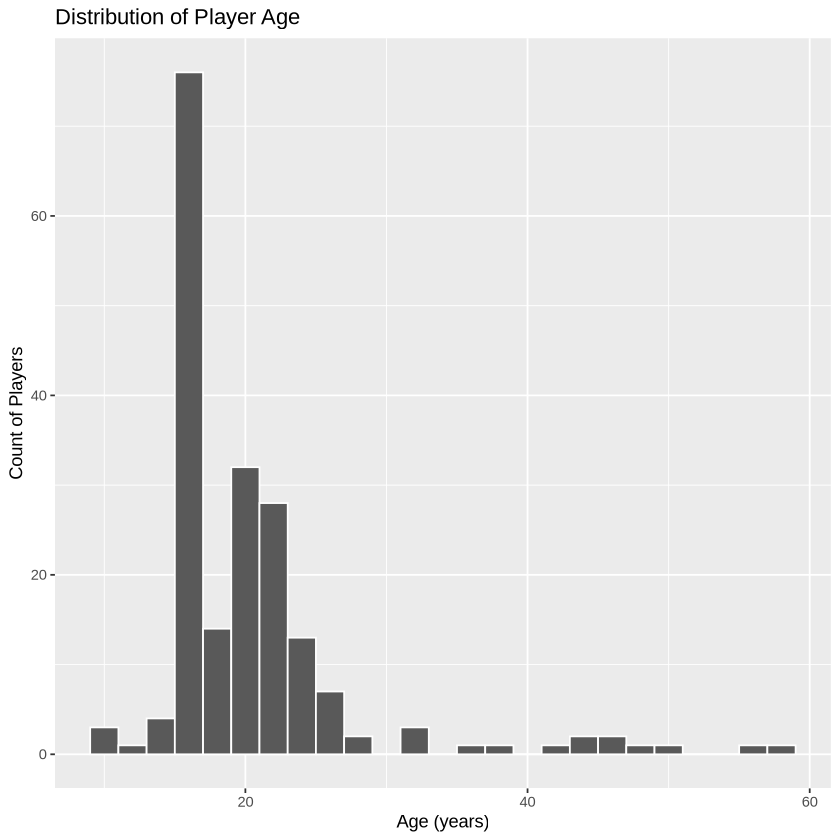

In [21]:
histo_age <- ggplot(players, aes(x = Age)) +
geom_histogram(binwidth = 2, color = "white") +
labs(title = "Distribution of Player Age", x = "Age (years)", y = "Count of Players")

histo_age

### Histogram of Played Hours

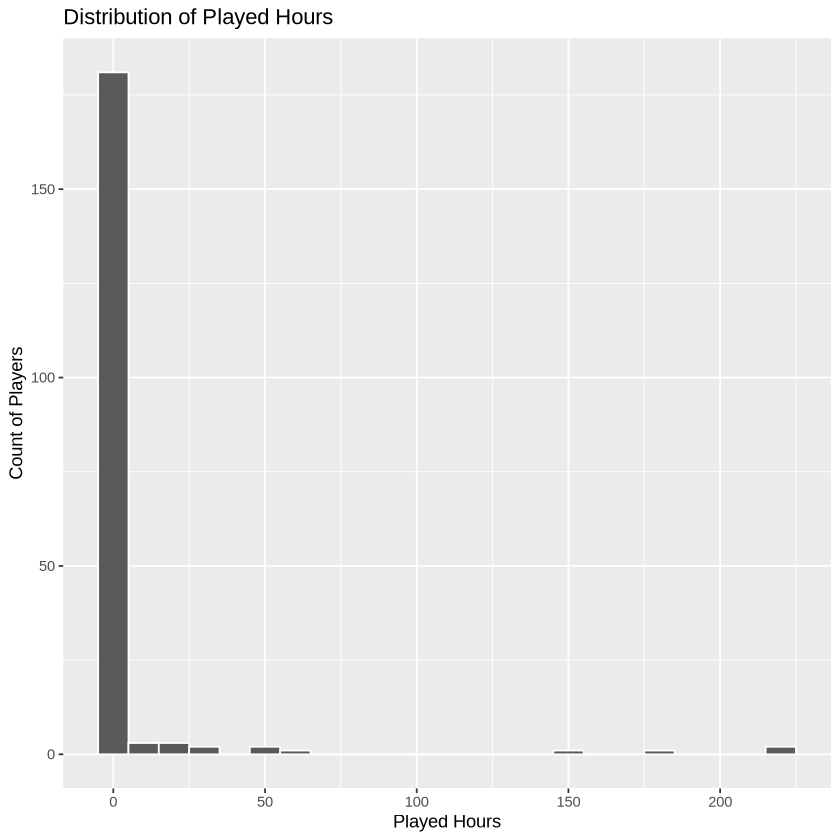

In [30]:
histo_phour <- ggplot(players, aes(x = played_hours)) +
  geom_histogram(binwidth = 10, color = "white") +
  labs(title = "Distribution of Played Hours", x = "Played Hours", y = "Count of Players") 

histo_phour

### Bar Chart of Average Played Hours by Age

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


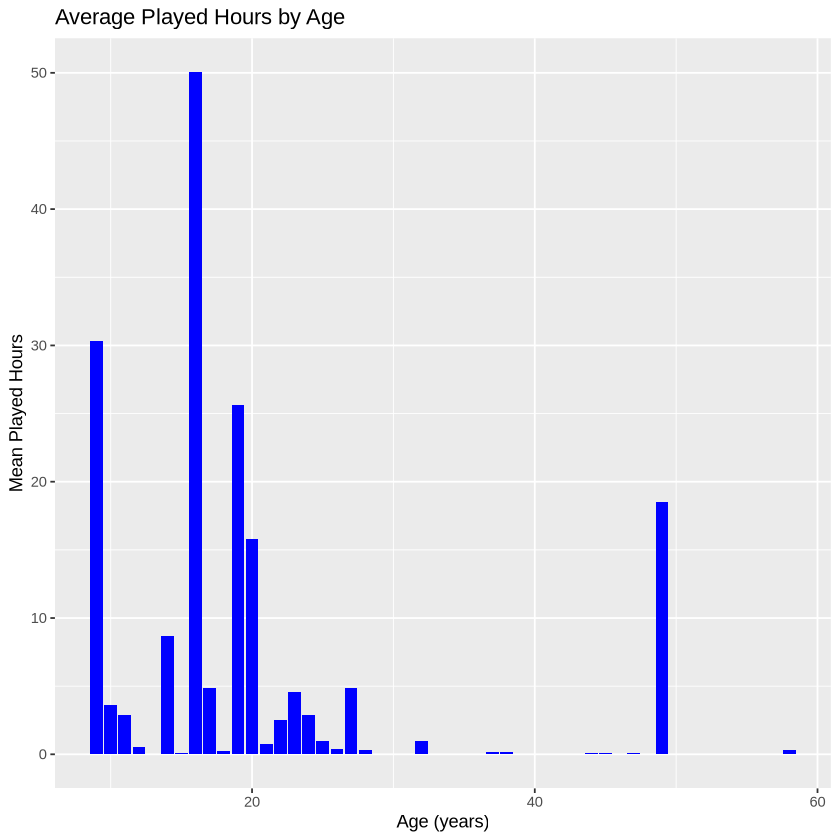

In [52]:
bar_final <- players |>
  group_by(Age) |>
  summarise(mean_hours = mean(played_hours, na.rm = TRUE)) |>
  ggplot(aes(x = Age, y = mean_hours)) +
  geom_bar(stat = "identity", fill = "blue") +
  labs(title = "Average Played Hours by Age", x = "Age (years)", y = "Mean Played Hours")

bar_final

### Insights

- Younger players show the highest average played hours.
- Average played hours generally decline as age increases.
- A few age groups (e.g., around 50) show spikes likely due to small sample sizes or outliers.
- This supports the idea that Age can be a meaningful predictor of played_hours.
- This pattern suggests younger players are more engaged, which could be essential for design and marketing. 

## Methods and Plan

My proposed method is the use of linear regression to model the relationship between the Age, explanatory variable, and the played_hours, response variable. The reason this is valid or appropriate is because our played_hours variable is numeric and continuous. Age is also numeric therefore making our linear regression an interpretable choice. The method will let us estimate how much played_hours changes with each progressively increasing year of age. There are some assumptions in this method such as assuming the relationship between Age and played_hours is approximately linear and that each player’s data is independent. To compare and select the model, I will start off with comparing the regression model against a baseline model that predicts the overall mean of played_hours for all players. Then, I would use simple metrics like RMSE (average error size) to judge improvement for selection. My plan for processing the data includes splitting the data into training (70%) and testing (30%) sets after wrangling. I will use cross‑validation (e.g., 5‑fold) on the training set to check for stability. I will also handle missing values and consider trimming extreme outliers in the data. Finally, the final evaluation on the test set using RMSE compared to baseline.

## Github Repository: 